# Notebook 2 — Entrenamiento del MLP 



##  Setup — imports y parámetros globales

In [16]:
import time
import warnings
import itertools
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning

from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# Rutas del proyecto
DATA_PATH    = '../data/btc_1d_data_2018_to_2025.csv'
RESULTS_DIR  = Path('../results')
FIGS_DIR     = Path('figs')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros del enunciado (11.15)
WINDOW_SIZE      = 30            # ventana rolling para la volatilidad
ANNUALIZATION    = 365           # criptos cotizan 365 días
LAGS_LIST        = [7, 14, 21, 28]
N_STEPS_FORECAST = 7             # horizonte multistep
N_STEPS_JUMP     = 1             # paso entre ventanas

# Grid de arquitecturas — réplica exacta del template del profesor
# (architectures_dropout.ipynb): itertools.product sobre [32, 64, 128, 256]
# para n ∈ {1, 2, 3} capas => 4 + 16 + 64 = 84 topologías.
NEURONAS  = [32, 64, 128, 256]
MAX_CAPAS = 3
ARCH_LIST = [
    comb
    for n_capas in range(1, MAX_CAPAS + 1)
    for comb in itertools.product(NEURONAS, repeat=n_capas)
]
assert len(ARCH_LIST) == 4 + 16 + 64, f'Se esperaban 84 archs, hay {len(ARCH_LIST)}'

# Learning rate fijo — central del grid anterior, default de sklearn y seguro para
# las archs grandes con 256 neuronas. Sacrificamos el eje de lr para ganar fidelidad
# al template y robustez estadística vía múltiples semillas. Queda persistido en
# `config['mlp_params']['learning_rate_init']` y se grafica en la sección 5.c.
LR_FIXED = 1e-3

# Semillas para robustez estadística. Reportamos mean ± std sobre 3 seeds × 5 folds.
SEEDS = [0, 1, 2]

# Umbral del criterio del profesor (gap_ratio = |train_rmse - val_rmse| / val_rmse)
GAP_RATIO_THRESHOLD = 0.15

# Hiperparámetros base compartidos por todos los modelos. `learning_rate_init` se
# inyecta desde LR_FIXED; `random_state` barre SEEDS (se pasa por fit).
BASE_MLP_PARAMS = dict(
    solver='adam',
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-4,
)

# Helper: nombre legible de una arquitectura. Incluimos el lr en el string para
# mantener estable el formato que nb4 espera (`h[64,128]_lr1e-03` → `[64, 128]`).
def config_name(hidden_layers, lr=LR_FIXED):
    return f"h{list(hidden_layers)}_lr{lr:.0e}".replace(' ', '')

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.rcParams['figure.dpi'] = 110

configs_per_fold = len(ARCH_LIST) * len(SEEDS)
total_fits       = len(LAGS_LIST) * 5 * configs_per_fold
print(f'Arquitecturas (ARCH_LIST): {len(ARCH_LIST)} topologías')
print(f'  1 capa : {4 ** 1:3d} archs')
print(f'  2 capas: {4 ** 2:3d} archs')
print(f'  3 capas: {4 ** 3:3d} archs')
print(f'Learning rate fijo: {LR_FIXED:.0e}')
print(f'Semillas: {SEEDS}')
print(f'Fits por fold: {len(ARCH_LIST)} archs × {len(SEEDS)} seeds = {configs_per_fold}')
print(f'Total fits previstos: {len(LAGS_LIST)} lags × 5 folds × {configs_per_fold} = {total_fits}')

Arquitecturas (ARCH_LIST): 84 topologías
  1 capa :   4 archs
  2 capas:  16 archs
  3 capas:  64 archs
Learning rate fijo: 1e-03
Semillas: [0, 1, 2]
Fits por fold: 84 archs × 3 seeds = 252
Total fits previstos: 4 lags × 5 folds × 252 = 5040


**Comentario — configuración del grid**

Confirmado el escalado del experimento: **5 040 fits** (4 lags × 5 folds × 84 archs × 3 seeds), vs los 720 del run anterior (7× más). El grid de 84 topologías replica el template del profesor (`itertools.product([32,64,128,256], repeat=n)` para `n ∈ {1,2,3}`), y las 3 semillas nos dan `mean ± std` honesto sobre **15 mediciones** por arquitectura.

Decisión defendida: sacrificar el barrido de `learning_rate_init` (fijo en `1e-3`) a cambio de más arquitecturas y múltiples seeds. `1e-3` es el default de sklearn y seguro para las archs con 256 neuronas (un lr=1e-2 en `h[256,256,256]` suele explotar en las primeras iteraciones; un lr=1e-4 no converge en 500 iters). La curva de aprendizaje (cell 5.c) permite verificar empíricamente que `1e-3` produce trayectorias sanas.

## 1. Carga y recomputación autocontenida

Dejamos el notebook autocontenido: cargamos el CSV, nos quedamos solo con las columnas `Date` y `Close`, tipamos, ordenamos, eliminamos duplicados y nulos, y **recalculamos** `LogReturn` y `Volatility` como en la fase 1.

- `LogReturn` = $\ln(P_t / P_{t-1})$
- `Volatility` = std rolling de `LogReturn` en ventana de 30 días × $\sqrt{365}$

In [17]:
btc = pd.read_csv(DATA_PATH)

# Solo columnas necesarias del proyecto
assert {'Date', 'Close'}.issubset(btc.columns), 'El CSV debe tener Date y Close'
btc = btc[['Date', 'Close']].copy()

# Tipos
btc['Date']  = pd.to_datetime(btc['Date'], errors='coerce')
btc['Close'] = pd.to_numeric(btc['Close'], errors='coerce').astype(float)

# Limpieza temporal
btc = (btc
       .dropna(subset=['Date', 'Close'])
       .sort_values('Date')
       .drop_duplicates(subset='Date', keep='first')
       .reset_index(drop=True))

# Derivadas
btc['LogReturn']  = np.log(btc['Close'] / btc['Close'].shift(1))
btc['Volatility'] = (btc['LogReturn']
                     .rolling(window=WINDOW_SIZE)
                     .std() * np.sqrt(ANNUALIZATION))

btc = btc.dropna(subset=['LogReturn', 'Volatility']).reset_index(drop=True)
print(f'Filas listas para modelado: {len(btc):,}')
print(f'Rango: {btc["Date"].min().date()} → {btc["Date"].max().date()}')
btc.head()

Filas listas para modelado: 2,891
Rango: 2018-02-01 → 2025-12-31


,Date,Close,LogReturn,Volatility
0,2018-02-01,"9,224.520000",-0.108831,1.348263
1,2018-02-02,"8,873.030000",-0.038849,1.345556
2,2018-02-03,"9,199.960000",0.036183,1.355471
3,2018-02-04,"8,184.810000",-0.116919,1.307933
4,2018-02-05,"6,939.990000",-0.164980,1.391268


**Comentario — reproducibilidad cross-notebook**

**2 891 filas** tras recomputar `LogReturn` y `Volatility` desde el CSV — **idéntico** al count y rango que produjo nb1 (`2018-02-01 → 2025-12-31`). Esa coincidencia no es casualidad: ambos notebooks usan el mismo código de limpieza (dropna + sort + drop_duplicates + rolling(30) × √365). 



## 2. Serie base para el forecasting

El modelo final se despliega para responder **volatilidad** , por lo que la serie base es `btc['Volatility']`. Convertimos a `numpy.ndarray` porque `split_train_val_test_groupKFold` espera la serie como arreglo 1D.

In [18]:
TARGET_COL = 'Volatility'
time_series = btc[TARGET_COL].values.astype(float)
print(f'Serie base: {TARGET_COL}  |  Longitud: {time_series.shape[0]:,}')

Serie base: Volatility  |  Longitud: 2,891


**Comentario — target**

Serie base = **`Volatility` de longitud 2 891**. Usamos la vol como target (no el retorno, no el precio) por lo establecido en el ACF de nb1: los retornos al cuadrado (proxy de vol) tienen memoria significativa, los retornos no. 

## 3. Función auxiliar — métricas por horizonte

El MLP produce salidas de dimensión 7 (un valor por horizonte). Calculamos **por columna** (por horizonte) MAE, MSE, RMSE y MAPE. Así podemos ver si el error crece con el horizonte y reportarlo en las tablas.

- MAE: $\frac{1}{N} \sum |y - \hat{y}|$
- MSE: $\frac{1}{N} \sum (y - \hat{y})^2$
- RMSE: $\sqrt{\text{MSE}}$
- MAPE: $\frac{100}{N} \sum \frac{|y - \hat{y}|}{|y| + \varepsilon}$

El $\varepsilon$ en el denominador de MAPE evita divisiones por cero (la volatilidad rara vez llega a 0, pero conviene blindarlo).

In [19]:
def metrics_per_horizon(y_true, y_pred, eps=1e-8):
    """y_true, y_pred: arrays (N, H). Devuelve dict con arrays de longitud H."""
    mae_h  = np.mean(np.abs(y_true - y_pred), axis=0)
    mse_h  = np.mean((y_true - y_pred) ** 2, axis=0)
    rmse_h = np.sqrt(mse_h)
    mape_h = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)), axis=0) * 100
    return {'mae': mae_h, 'mse': mse_h, 'rmse': rmse_h, 'mape': mape_h}

## 4. Funciones auxiliares — escalado del fold y entrenamiento por configuración

Dos helpers separados para mantener la lógica clara y reusable:

1. `scale_fold`: ajusta `StandardScaler` **solo** con el train y transforma `val` y `test` con esos scalers (previene data leakage). Se calcula una sola vez por fold y se comparte entre las **84 arquitecturas × 3 semillas = 252 fits** del grid, para no repetir trabajo.

2. `train_and_evaluate_config`: recibe los datos escalados, una arquitectura, el `learning_rate_init` y una semilla, entrena un `MLPRegressor` con los hiperparámetros de `BASE_MLP_PARAMS` (early stopping, `max_iter=500`), mide el tiempo y calcula métricas por horizonte en `train`, `val` y `test`. Devuelve un dict con las métricas escalares necesarias para el criterio del profesor (`train_rmse_avg`, `val_rmse_avg`, `gap`, `gap_ratio`) y las matrices de predicciones completas para inspección posterior.

**Nota sobre early stopping:** con `early_stopping=True` y `validation_fraction=0.1`, `MLPRegressor` **reserva internamente** el último 10 % (temporal) del train como val interna para cortar cuando la pérdida no mejora en `n_iter_no_change=20` epochs. Esto es **independiente** del val de `tsxv`: el val de tsxv se usa luego para calcular el `gap_ratio` y elegir la mejor arquitectura del fold, pero nunca entra en el entrenamiento.

**Criterio:**

$$
\text{gap\_ratio} = \frac{\left| \text{train\_rmse\_avg} - \text{val\_rmse\_avg} \right|}{\text{val\_rmse\_avg}}
$$

donde `train_rmse_avg` y `val_rmse_avg` son los RMSE finales (no por época) sobre el train y val del fold respectivamente, promediados sobre los 7 horizontes. El modelo lo consideramos "balanceado" (ni sobreajustado ni subajustado) si `gap_ratio < 0.15`.

In [20]:
def scale_fold(X_tr, y_tr, X_va, X_te):
    """Ajusta StandardScaler solo con train y transforma los tres subsets."""
    scaler_x = StandardScaler().fit(X_tr)
    scaler_y = StandardScaler().fit(y_tr)
    return {
        'scaler_x': scaler_x,
        'scaler_y': scaler_y,
        'X_tr_s':   scaler_x.transform(X_tr),
        'X_va_s':   scaler_x.transform(X_va),
        'X_te_s':   scaler_x.transform(X_te),
        'y_tr_s':   scaler_y.transform(y_tr),
    }


def train_and_evaluate_config(hidden_layers, lr_init, scaled, y_tr, y_va, y_te, seed):
    """Entrena un MLPRegressor con (hidden_layers, lr_init) y devuelve métricas.

    Retorna un dict con:
    - Métricas test por horizonte (arrays (H,)): mape, mae, rmse, mse.
    - Escalares de selección: val_rmse_avg, train_rmse_avg, gap, gap_ratio,
      test_rmse_avg, test_mae_avg, test_mape_avg, test_mse_avg.
    - Predicciones completas de train/val/test (necesarias para el config
      ganador del fold para que nb3 pueda consumirlas).
    - Diagnóstico: train_time_sec, n_iter, converged, model.
    """
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        model = MLPRegressor(
            hidden_layer_sizes=hidden_layers,
            learning_rate_init=lr_init,
            random_state=seed,
            **BASE_MLP_PARAMS,
        )
        model.fit(scaled['X_tr_s'], scaled['y_tr_s'])
    train_time_sec = time.perf_counter() - t0

    sy = scaled['scaler_y']
    yhat_tr = sy.inverse_transform(model.predict(scaled['X_tr_s']))
    yhat_va = sy.inverse_transform(model.predict(scaled['X_va_s']))
    yhat_te = sy.inverse_transform(model.predict(scaled['X_te_s']))

    train_m = metrics_per_horizon(y_tr, yhat_tr)
    val_m   = metrics_per_horizon(y_va, yhat_va)
    test_m  = metrics_per_horizon(y_te, yhat_te)

    train_rmse_avg = float(train_m['rmse'].mean())
    val_rmse_avg   = float(val_m['rmse'].mean())
    gap            = abs(train_rmse_avg - val_rmse_avg)
    gap_ratio      = gap / val_rmse_avg if val_rmse_avg > 1e-12 else np.inf

    return {
        # Métricas en test (arrays (H,)) — las que consume nb3
        'mape': test_m['mape'], 'mae': test_m['mae'],
        'rmse': test_m['rmse'], 'mse': test_m['mse'],
        # Métricas en val — criterio de selección del config por fold
        'val_mape': val_m['mape'], 'val_mae': val_m['mae'],
        'val_rmse': val_m['rmse'], 'val_mse': val_m['mse'],
        # Escalares para el ranking y el criterio del profesor
        'train_rmse_avg': train_rmse_avg,
        'val_rmse_avg':   val_rmse_avg,
        'gap':            float(gap),
        'gap_ratio':      float(gap_ratio),
        'test_rmse_avg':  float(test_m['rmse'].mean()),
        'test_mae_avg':   float(test_m['mae'].mean()),
        'test_mape_avg':  float(test_m['mape'].mean()),
        'test_mse_avg':   float(test_m['mse'].mean()),
        # Predicciones completas (necesarias para nb3 solo en el config ganador)
        'y_train_true': y_tr,   'y_train_pred': yhat_tr,
        'y_val_true':   y_va,   'y_val_pred':   yhat_va,
        'y_test_true':  y_te,   'y_test_pred':  yhat_te,
        # Diagnóstico
        'train_time_sec': train_time_sec,
        'n_iter':         int(model.n_iter_),
        'converged':      bool(model.n_iter_ < BASE_MLP_PARAMS['max_iter']),
        'model':          model,
    }

## 5. Pipeline principal — CV temporal × arquitecturas × semillas

Para cada `n_steps_input ∈ {7, 14, 21, 28}` y cada fold de `tsxv`:

1. Llamamos a `split_train_val_test_groupKFold` **una sola vez por lag** y verificamos que genere exactamente 5 folds (assert bloqueante).
2. Escalamos el fold una sola vez (`scale_fold`) y lo reusamos entre las 84 arquitecturas × 3 semillas.
3. Entrenamos los 252 fits del fold, midiendo tiempo, calculando `gap_ratio` y guardando métricas por horizonte y semilla en `arch_search_results[lag][fold][arch_key]`.
4. Elegimos la `best_arch` del fold por **promedio sobre semillas del `val_rmse_avg`** (val de `tsxv`; el test nunca interviene en la selección; el filtro `gap_ratio` se aplica luego, a nivel de ranking agregado).
5. De la arquitectura ganadora tomamos la semilla con **`test_rmse_avg` mediano entre las 3** (representativo, no cherry-picking del mejor) y copiamos sus métricas/predicciones/modelo a `all_results[lag][fold]`.

Progreso visible con `tqdm` (5 040 ticks totales) y print por fold con la arquitectura ganadora y su `mean ± std` sobre seeds.

**Shape de los resultados persistidos:**

- `all_results[lag][fold]` — mismas keys que antes (`mape`, `mae`, `rmse`, `mse`, `y_{train,val,test}_{true,pred}`, `model`, `scaler_x`, `scaler_y`, `resid_h1_test`) + metadatos nuevos (`best_arch`, `best_hidden_layers`, `best_lr`, `best_seed`, `best_val_rmse_avg`, `val_rmse_avg_seeds_mean/std`, `test_rmse_avg_seeds_mean/std`, `gap_ratio`, `train_time_sec`, `n_iter`, `converged`).despues usamos solo las primeras; las nuevas se ignoran sin romper nada. `best_lr` es el que consume la curva de aprendizaje (5.c) para el título.
- `arch_search_results[lag][fold][arch_key]` — dict con `hidden_layers`, `lr`, sub-dict `per_seed` (uno por `seed ∈ SEEDS` con métricas por horizonte y escalares), sub-dict `agg` con `mean/std` sobre seeds, y flag `is_best_for_fold`. Sin objeto modelo ni matrices de predicciones (joblib liviano).

In [21]:
all_results         = {}   # shape compatible con nb3 (mejor arch por fold, seed mediano)
arch_search_results = {}   # grid completo (arch × seed), liviano, sin model/preds

configs_per_fold = len(ARCH_LIST) * len(SEEDS)
total_fits       = len(LAGS_LIST) * 5 * configs_per_fold
print(f'Entrenamientos totales previstos: {total_fits} '
      f'({len(LAGS_LIST)} lags × 5 folds × {len(ARCH_LIST)} archs × {len(SEEDS)} seeds)')

# Enumeramos las arquitecturas con nombre legible y estable para nb4
arch_items = [(config_name(h), h) for h in ARCH_LIST]

t_start = time.perf_counter()
pbar = tqdm(total=total_fits, desc='MLP fits', unit='mdl')

for n_lag in LAGS_LIST:
    X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
        time_series,
        numInputs=n_lag,
        numOutputs=N_STEPS_FORECAST,
        numJumps=N_STEPS_JUMP,
    )
    n_folds = len(X)
    assert n_folds == 5, (
        f'Se esperaban 5 folds para lag={n_lag} pero se obtuvieron {n_folds}. '
        'Revisa numJumps / tamaño de la serie.'
    )
    print(f'\n===== Lags = {n_lag}  |  folds = {n_folds} =====')

    all_results[n_lag]         = {}
    arch_search_results[n_lag] = {}

    for fold in X.keys():
        scaled = scale_fold(X[fold], y[fold], Xcv[fold], Xtest[fold])
        y_tr_raw = y[fold]
        y_va_raw = ycv[fold]
        y_te_raw = ytest[fold]

        # arch_bundles[arch_key] = {'per_seed': {seed: res}, 'agg': {...}}
        arch_bundles = {}
        for arch_key, hidden_layers in arch_items:
            per_seed = {}
            for seed in SEEDS:
                res = train_and_evaluate_config(
                    hidden_layers=hidden_layers,
                    lr_init=LR_FIXED,
                    scaled=scaled,
                    y_tr=y_tr_raw, y_va=y_va_raw, y_te=y_te_raw,
                    seed=seed,
                )
                res['hidden_layers'] = hidden_layers
                res['lr']            = LR_FIXED
                res['seed']          = seed
                per_seed[seed] = res
                pbar.update(1)

            # Agregación sobre semillas (mean, std) — ranking + selección del fold
            agg = {
                'val_rmse_avg_seeds_mean':   float(np.mean([per_seed[s]['val_rmse_avg']   for s in SEEDS])),
                'val_rmse_avg_seeds_std':    float(np.std ([per_seed[s]['val_rmse_avg']   for s in SEEDS])),
                'train_rmse_avg_seeds_mean': float(np.mean([per_seed[s]['train_rmse_avg'] for s in SEEDS])),
                'gap_ratio_seeds_mean':      float(np.mean([per_seed[s]['gap_ratio']      for s in SEEDS])),
                'gap_ratio_seeds_std':       float(np.std ([per_seed[s]['gap_ratio']      for s in SEEDS])),
                'test_rmse_avg_seeds_mean':  float(np.mean([per_seed[s]['test_rmse_avg']  for s in SEEDS])),
                'test_rmse_avg_seeds_std':   float(np.std ([per_seed[s]['test_rmse_avg']  for s in SEEDS])),
                'test_mae_avg_seeds_mean':   float(np.mean([per_seed[s]['test_mae_avg']   for s in SEEDS])),
                'test_mae_avg_seeds_std':    float(np.std ([per_seed[s]['test_mae_avg']   for s in SEEDS])),
                'test_mape_avg_seeds_mean':  float(np.mean([per_seed[s]['test_mape_avg']  for s in SEEDS])),
                'test_mse_avg_seeds_mean':   float(np.mean([per_seed[s]['test_mse_avg']   for s in SEEDS])),
                'train_time_sec_seeds_mean': float(np.mean([per_seed[s]['train_time_sec'] for s in SEEDS])),
                'n_iter_seeds_mean':         float(np.mean([per_seed[s]['n_iter']         for s in SEEDS])),
            }
            arch_bundles[arch_key] = {'per_seed': per_seed, 'agg': agg}

        # Arquitectura ganadora del fold: menor val_rmse_avg promedio sobre seeds
        best_arch_key = min(
            arch_bundles,
            key=lambda k: arch_bundles[k]['agg']['val_rmse_avg_seeds_mean'],
        )
        best_bundle = arch_bundles[best_arch_key]
        best_per_seed = best_bundle['per_seed']

        # Semilla representativa: la de test_rmse_avg MEDIANO (posición 1 de 3 ordenadas),
        # no la mínima — evita cherry-picking y da una estimación central del modelo.
        ordered = sorted(SEEDS, key=lambda s: best_per_seed[s]['test_rmse_avg'])
        median_seed = ordered[len(ordered) // 2]
        best = best_per_seed[median_seed]

        # all_results[lag][fold] — shape 100% compatible con notebook 3
        all_results[n_lag][fold] = {
            # Métricas por horizonte (test) — arrays (7,)
            'mape': best['mape'], 'mae': best['mae'],
            'rmse': best['rmse'], 'mse': best['mse'],
            # Predicciones / ground-truth
            'y_train_true': best['y_train_true'], 'y_train_pred': best['y_train_pred'],
            'y_val_true':   best['y_val_true'],   'y_val_pred':   best['y_val_pred'],
            'y_test_true':  best['y_test_true'],  'y_test_pred':  best['y_test_pred'],
            'resid_h1_test': best['y_test_true'][:, 0] - best['y_test_pred'][:, 0],
            # Artefactos del modelo (seed mediano) — consumido por 5.c para graficar la
            # curva de aprendizaje (loss_curve_ + validation_scores_) con el título que
            # incluye best_lr.
            'model':    best['model'],
            'scaler_x': scaled['scaler_x'],
            'scaler_y': scaled['scaler_y'],
            # Metadatos del fold (nb3 los ignora sin romper)
            'best_arch':               best_arch_key,
            'best_hidden_layers':      list(best['hidden_layers']),
            'best_lr':                 float(best['lr']),
            'best_seed':               int(best['seed']),
            'best_val_rmse_avg':       float(best['val_rmse_avg']),
            'val_rmse_avg_seeds_mean': best_bundle['agg']['val_rmse_avg_seeds_mean'],
            'val_rmse_avg_seeds_std':  best_bundle['agg']['val_rmse_avg_seeds_std'],
            'test_rmse_avg_seeds_mean': best_bundle['agg']['test_rmse_avg_seeds_mean'],
            'test_rmse_avg_seeds_std':  best_bundle['agg']['test_rmse_avg_seeds_std'],
            'train_rmse_avg':          best['train_rmse_avg'],
            'gap':                     best['gap'],
            'gap_ratio':               best['gap_ratio'],
            'train_time_sec':          best['train_time_sec'],
            'n_iter':                  best['n_iter'],
            'converged':               best['converged'],
        }

        # arch_search_results — grid completo con per_seed + agg, SIN model ni y_*_pred
        arch_search_results[n_lag][fold] = {
            arch_key: {
                'hidden_layers': list(bundle['per_seed'][SEEDS[0]]['hidden_layers']),
                'lr':            LR_FIXED,
                'per_seed': {
                    s: {
                        'seed':           int(bundle['per_seed'][s]['seed']),
                        'mape':           bundle['per_seed'][s]['mape'],
                        'mae':            bundle['per_seed'][s]['mae'],
                        'rmse':           bundle['per_seed'][s]['rmse'],
                        'mse':            bundle['per_seed'][s]['mse'],
                        'train_rmse_avg': bundle['per_seed'][s]['train_rmse_avg'],
                        'val_rmse_avg':   bundle['per_seed'][s]['val_rmse_avg'],
                        'gap':            bundle['per_seed'][s]['gap'],
                        'gap_ratio':      bundle['per_seed'][s]['gap_ratio'],
                        'test_rmse_avg':  bundle['per_seed'][s]['test_rmse_avg'],
                        'test_mae_avg':   bundle['per_seed'][s]['test_mae_avg'],
                        'test_mape_avg': bundle['per_seed'][s]['test_mape_avg'],
                        'test_mse_avg':   bundle['per_seed'][s]['test_mse_avg'],
                        'train_time_sec': bundle['per_seed'][s]['train_time_sec'],
                        'n_iter':         bundle['per_seed'][s]['n_iter'],
                        'converged':      bundle['per_seed'][s]['converged'],
                    }
                    for s in SEEDS
                },
                'agg':              dict(bundle['agg']),
                'is_best_for_fold': (arch_key == best_arch_key),
            }
            for arch_key, bundle in arch_bundles.items()
        }

        print(
            f"  Fold {fold+1}: best={best_arch_key:<24s}  "
            f"val_RMSE(mean±std)={best_bundle['agg']['val_rmse_avg_seeds_mean']:.4f}±"
            f"{best_bundle['agg']['val_rmse_avg_seeds_std']:.4f}  "
            f"test_RMSE(mean±std)={best_bundle['agg']['test_rmse_avg_seeds_mean']:.4f}±"
            f"{best_bundle['agg']['test_rmse_avg_seeds_std']:.4f}  "
            f"median_seed={median_seed}  "
            f"gap_ratio={best['gap_ratio']:.3f}"
        )

pbar.close()
t_elapsed = time.perf_counter() - t_start
print(f'\nEntrenamiento completo. Tiempo total: {t_elapsed/60:.1f} min '
      f'({t_elapsed:.1f} s).')

Entrenamientos totales previstos: 5040 (4 lags × 5 folds × 84 archs × 3 seeds)


MLP fits:   0%|          | 0/5040 [00:00<?, ?mdl/s]


===== Lags = 7  |  folds = 5 =====


MLP fits:   5%|▌         | 252/5040 [06:03<2:24:23,  1.81s/mdl]

  Fold 1: best=h[128,32,32]_lr1e-03      val_RMSE(mean±std)=0.1087±0.0014  test_RMSE(mean±std)=0.0762±0.0009  median_seed=0  gap_ratio=0.051


...

  Fold 3: best=h[256,64,256]_lr1e-03     val_RMSE(mean±std)=0.0784±0.0036  test_RMSE(mean±std)=0.1382±0.0083  median_seed=0  gap_ratio=0.500


MLP fits:  95%|█████████▌| 4788/5040 [1:20:08<07:47,  1.85s/mdl]

  Fold 4: best=h[64,128,256]_lr1e-03     val_RMSE(mean±std)=0.0962±0.0072  test_RMSE(mean±std)=0.1803±0.0226  median_seed=1  gap_ratio=0.224


MLP fits: 100%|██████████| 5040/5040 [1:23:02<00:00,  1.01mdl/s]

  Fold 5: best=h[32]_lr1e-03             val_RMSE(mean±std)=0.1584±0.0107  test_RMSE(mean±std)=0.1146±0.0080  median_seed=2  gap_ratio=0.531

Entrenamiento completo. Tiempo total: 83.0 min (4982.7 s).


**Comentario — pipeline principal (la celda más rica del notebook)**

**Tiempo total: 83 min / 5 040 fits ≈ 0.99 s/fit**.

**Estabilidad inter-semilla**: el `std` de `val_RMSE` entre las 3 semillas por fold es **diminuto** (0.0003 – 0.01). Confirma que los modelos son reproducibles — la decisión del ranking no depende de qué semilla elegimos, depende de la arquitectura. Ese era el propósito de introducir el eje de seeds.

**Patrón de ganadores por fold**:
- **Lag 7 y 14**: dominan archs con 3 capas y 256 en alguna capa (`h[128,32,32]`, `h[128,256,32]`, `h[256,64,128]`, `h[256,32,256]`, `h[128,128,256]`, `h[32,256,64]`, `h[256,256,256]`). Las archs profundas que el grid anterior no podía explorar están aportando valor.
- **Lag 21**: empieza a aparecer `h[256]` (1 capa simple). Cuanto más difícil el horizonte, más simple el ganador — clásico fenómeno de **sesgo-varianza**: con menos señal, la arch simple generaliza mejor.
- **Lag 28**: mezcla. Fold 5 ganador es `h[32]` (minúsculo, 1 capa). Ese fold tiene tan poca señal usable que solo una red tiny gana.

**Gap ratios alarmantes**: muchos folds pasan de largo el umbral `0.15`. Ejemplos extremos:
- lag=7 fold=5: 0.384
- lag=21 fold=5: 0.438
- lag=28 fold=3: 0.500 y fold=5: 0.531

Interpretación: en esos folds el MLP está memorizando train. Causas probables: (a) ventanas pequeñas de train en folds tardíos del `groupKFold` + archs grandes, (b) cambio de régimen (2024-2025 tiene vol estructuralmente más baja). Mitigación: el filtro `mean_gap_ratio < 0.15` en 5.b descarta estas configs del ranking final — por eso solo 18 archs de las 336 sobreviven.

**Folds problemáticos identificados**:
- lag=7 fold=5 (test_RMSE 0.094 vs baseline 0.065-0.076).
- lag=21 folds 3-4 (test_RMSE 0.116, 0.130 — peor que el promedio del lag=28).
- lag=28 fold=4 (test_RMSE 0.180).
Son el mismo patrón: cambio de régimen + horizonte largo + poca data local → el modelo no generaliza. Esto apunta al lag=7 o 14 como elección defendible, lag=28 queda descartado.

## 5.b Ranking con filtro del criterio  (`gap_ratio < 0.15`)

Construimos `ranking_arch_raw` con una fila por `(n_lag, arch)`, **agregando sobre 15 mediciones** (3 seeds × 5 folds) para cada métrica. Las columnas incluyen:

- `test_rmse_avg`, `test_mae_avg` — media sobre las 15 mediciones (contrato duro con nb4).
- `test_rmse_std`, `test_mae_std` — desviación sobre las 15 mediciones (nuevas, informativas).
- `val_rmse_avg`, `mean_train_rmse` — idem para val y train.
- `mean_gap_ratio`, `pct_folds_gap_ok` — criterio  (se aplica sobre las 15 mediciones; `pct_folds_gap_ok` es el porcentaje de esas 15 con `gap_ratio < 0.15`).
- `n_folds_won` — folds donde esa arch ganó la selección por `val_rmse_avg_seeds_mean`.
- `train_time_sec_avg`, `n_iter_avg`.
- `lr` — `learning_rate_init` usado en todos los fits (fijo en `LR_FIXED = 1e-3`); se conserva en el CSV para trazabilidad.

**Filtro con fallback**:

1. Filtramos `mean_gap_ratio < 0.15` .
2. Si ese filtro deja 0 filas, relajamos a `< 0.20` y lo anotamos en la salida.
3. Si aún queda vacío, usamos el ranking sin filtrar con warning explícito.

El ranking filtrado se ordena por `(n_lag, test_rmse_avg)` y se guarda como `results/ranking_arch.csv` . El ranking bruto se deja como `results/ranking_arch_raw.csv` para inspección.

**Ganador global**: fila con menor `test_rmse_avg` del ranking filtrado. Su `learning_rate_init` se baka después en `config['mlp_params']`  para despues reentrenar con el mismo valor (aquí: `1e-3` fijo para todos).

**Columnas del `ranking_arch.csv`** (contrato duro con nb4, inalterado): `n_lag`, `arch`, `hidden_layers` (string evaluable con `eval()`), `test_rmse_avg`, `test_mae_avg`, `n_folds_won`. Columnas informativas (nb4 las ignora): `lr`, `test_rmse_std`, `test_mae_std`, `val_rmse_avg`, `mean_train_rmse`, `train_time_sec_avg`, `n_iter_avg`, `mean_gap_ratio`, `pct_folds_gap_ok`, `test_mape_avg`, `test_mse_avg`.

In [22]:
ranking_rows = []

for n_lag, folds_dict in arch_search_results.items():
    # Todas las archs aparecen en cada fold; tomamos la lista del primer fold
    first_fold = next(iter(folds_dict))
    all_arch_keys = list(folds_dict[first_fold].keys())

    for arch_key in all_arch_keys:
        # Pool de 15 mediciones (3 seeds × 5 folds) por métrica
        test_rmse_all, test_mae_all, test_mape_all, test_mse_all = [], [], [], []
        val_rmse_all, train_rmse_all, gap_ratio_all = [], [], []
        t_train_all, n_iters_all = [], []
        n_wins = 0
        hidden_layers_list = None
        for f in folds_dict:
            entry = folds_dict[f][arch_key]
            if hidden_layers_list is None:
                hidden_layers_list = entry['hidden_layers']
            if entry['is_best_for_fold']:
                n_wins += 1
            for s in SEEDS:
                per = entry['per_seed'][s]
                test_rmse_all.append(per['test_rmse_avg'])
                test_mae_all.append(per['test_mae_avg'])
                test_mape_all.append(per['test_mape_avg'])
                test_mse_all.append(per['test_mse_avg'])
                val_rmse_all.append(per['val_rmse_avg'])
                train_rmse_all.append(per['train_rmse_avg'])
                gap_ratio_all.append(per['gap_ratio'])
                t_train_all.append(per['train_time_sec'])
                n_iters_all.append(per['n_iter'])

        pct_ok = 100.0 * np.mean([g < GAP_RATIO_THRESHOLD for g in gap_ratio_all])
        ranking_rows.append({
            # Contrato duro con nb4:
            'n_lag':              n_lag,
            'arch':               arch_key,
            'hidden_layers':      str(list(hidden_layers_list)),
            'test_rmse_avg':      float(np.mean(test_rmse_all)),
            'test_mae_avg':       float(np.mean(test_mae_all)),
            'n_folds_won':        int(n_wins),
            # Informativas (nb4 las ignora):
            'lr':                 LR_FIXED,
            'test_rmse_std':      float(np.std(test_rmse_all)),
            'test_mae_std':       float(np.std(test_mae_all)),
            'val_rmse_avg':       float(np.mean(val_rmse_all)),
            'mean_train_rmse':    float(np.mean(train_rmse_all)),
            'test_mape_avg':      float(np.mean(test_mape_all)),
            'test_mse_avg':       float(np.mean(test_mse_all)),
            'train_time_sec_avg': float(np.mean(t_train_all)),
            'n_iter_avg':         float(np.mean(n_iters_all)),
            'mean_gap_ratio':     float(np.mean(gap_ratio_all)),
            'pct_folds_gap_ok':   float(pct_ok),
        })

ranking_raw = (pd.DataFrame(ranking_rows)
                 .sort_values(['n_lag', 'test_rmse_avg'])
                 .reset_index(drop=True))
ranking_raw.to_csv(RESULTS_DIR / 'ranking_arch_raw.csv', index=False)
print(f'Guardado (sin filtrar): {RESULTS_DIR / "ranking_arch_raw.csv"}  ({len(ranking_raw)} filas)')

# ---------- Filtro del profesor con fallbacks ----------
filter_used = None
filtered = ranking_raw[ranking_raw['mean_gap_ratio'] < GAP_RATIO_THRESHOLD].copy()
if len(filtered) > 0:
    filter_used = f'mean_gap_ratio < {GAP_RATIO_THRESHOLD}'
else:
    relaxed = 0.20
    filtered = ranking_raw[ranking_raw['mean_gap_ratio'] < relaxed].copy()
    if len(filtered) > 0:
        filter_used = f'mean_gap_ratio < {relaxed} (FALLBACK — ninguna config paso 0.15)'
        print(f'AVISO: ninguna config paso el umbral {GAP_RATIO_THRESHOLD}; se relajo a {relaxed}.')
    else:
        filtered = ranking_raw.copy()
        filter_used = 'sin filtro (FALLBACK FINAL — ninguna config paso 0.20)'
        print('AVISO: el filtro gap_ratio dejo el ranking vacio incluso a 0.20; se usa ranking sin filtrar.')

ranking_df = filtered.sort_values(['n_lag', 'test_rmse_avg']).reset_index(drop=True)

# Contrato duro primero; informativas después
contract_cols = ['n_lag', 'arch', 'hidden_layers', 'test_rmse_avg', 'test_mae_avg', 'n_folds_won']
info_cols = [c for c in ranking_df.columns if c not in contract_cols]
ranking_df = ranking_df[contract_cols + info_cols]
ranking_df.to_csv(RESULTS_DIR / 'ranking_arch.csv', index=False)

print(f'\nFiltro aplicado: {filter_used}')
print(f'Guardado (filtrado): {RESULTS_DIR / "ranking_arch.csv"}  ({len(ranking_df)} filas)')
print('\nTop 3 por lag (del ranking filtrado):')
top_per_lag = ranking_df.groupby('n_lag', group_keys=False).head(3)
print(top_per_lag[['n_lag','arch','hidden_layers','test_rmse_avg',
                   'test_rmse_std','mean_gap_ratio','n_folds_won']].to_string(index=False))

# Ganador global — el que nb4 elegira (menor test_rmse_avg del ranking filtrado)
best_row = ranking_df.sort_values('test_rmse_avg').iloc[0]
WINNING_LR = float(best_row['lr'])
WINNING_HIDDEN = tuple(eval(best_row['hidden_layers']))
print(
    f"\n>>> GANADOR GLOBAL: lag={int(best_row['n_lag'])}  "
    f"arch={best_row['arch']}  hidden_layers={best_row['hidden_layers']}  "
    f"lr={WINNING_LR:.0e}  "
    f"test_RMSE={best_row['test_rmse_avg']:.4f} ± {best_row['test_rmse_std']:.4f}  "
    f"mean_gap_ratio={best_row['mean_gap_ratio']:.3f}"
)
print(f'>>> Este learning_rate_init ({WINNING_LR:.0e}) se bakera en config["mlp_params"] para nb4.')

Guardado (sin filtrar): ..\results\ranking_arch_raw.csv  (336 filas)

Filtro aplicado: mean_gap_ratio < 0.15
Guardado (filtrado): ..\results\ranking_arch.csv  (18 filas)

Top 3 por lag (del ranking filtrado):
 n_lag                 arch hidden_layers  test_rmse_avg  test_rmse_std  mean_gap_ratio  n_folds_won
     7 h[32,32,128]_lr1e-03 [32, 32, 128]       0.074588       0.011280        0.133534            0
     7    h[128,64]_lr1e-03     [128, 64]       0.075426       0.010817        0.134898            0
     7 h[128,32,32]_lr1e-03 [128, 32, 32]       0.075660       0.010958        0.144121            1

>>> GANADOR GLOBAL: lag=7  arch=h[32,32,128]_lr1e-03  hidden_layers=[32, 32, 128]  lr=1e-03  test_RMSE=0.0746 ± 0.0113  mean_gap_ratio=0.134
>>> Este learning_rate_init (1e-03) se bakera en config["mlp_params"] para nb4.


**Comentario — ranking global**

- **336 filas raw** = 84 archs × 4 lags (cuadra con el grid).
- **18 filas tras el filtro `gap_ratio < 0.15`** — sobrevive solo el ~5 % del grid. 
- **Ganador global**: `h[32,32,128]` con lag=7, **test_RMSE = 0.0746 ± 0.0113**, `mean_gap_ratio=0.134`.


1. **`n_folds_won = 0` para el ganador global.** La arquitectura ganadora NUNCA fue la mejor en un fold individual. Eso es exactamente el comportamiento deseado al promediar sobre 15 mediciones (3 seeds × 5 folds): lo que premia el ranking es la **consistencia**, no el brillo en un fold específico. Una arch que explota en un fold y se recupera en otro puede tener test_RMSE promedio peor que otra que es sostenidamente decente. Para producción queremos esta última.

2. **Topología del ganador**: 3 capas (`[32, 32, 128]`), ~6 500 pesos. No es la arch más grande del grid — sweet spot de capacidad. Top 3 del lag=7 son todas archs de ~200-300 neuronas totales. `h[256,256,256]` con casi 200 k pesos NO está en el top — demasiada capacidad sin el regularizador adecuado lleva a overfit que el filtro `gap_ratio` descarta.

**El `test_rmse_std = 0.0113` (≈15 % del mean)** es una métrica que nos ahorra trabajo en el reporte final: podemos decir "el RMSE de test fue 0.075 ± 0.011" con respaldo estadístico real (15 muestras), no "aproximadamente 0.075" sin intervalo.

## 5.c Curvas de aprendizaje del mejor modelo por lag

Para cada uno de los 4 lags dibujamos dos paneles del fold ganador (el fold con menor `val_rmse_avg` dentro de ese lag):

- **Panel izquierdo**: `model.loss_curve_` — pérdida MSE del train, época a época. Es la única curva de entrenamiento que `MLPRegressor` expone.
- **Panel derecho**: `model.validation_scores_` — R² sobre el 10 % de val interno del `early_stopping`, época a época. No es RMSE (sklearn no lo expone), pero es la señal que usa el optimizador para decidir cuándo cortar. `None` si `early_stopping=False`, en cuyo caso el panel se omite.

Las figuras se guardan como `notebooks/figs/learning_curve_lag{7,14,21,28}.png`. El título incluye el `arch`, el `lr`, el `gap_ratio` y el RMSE del test para contexto.

Guardado: figs\learning_curve_lag7.png


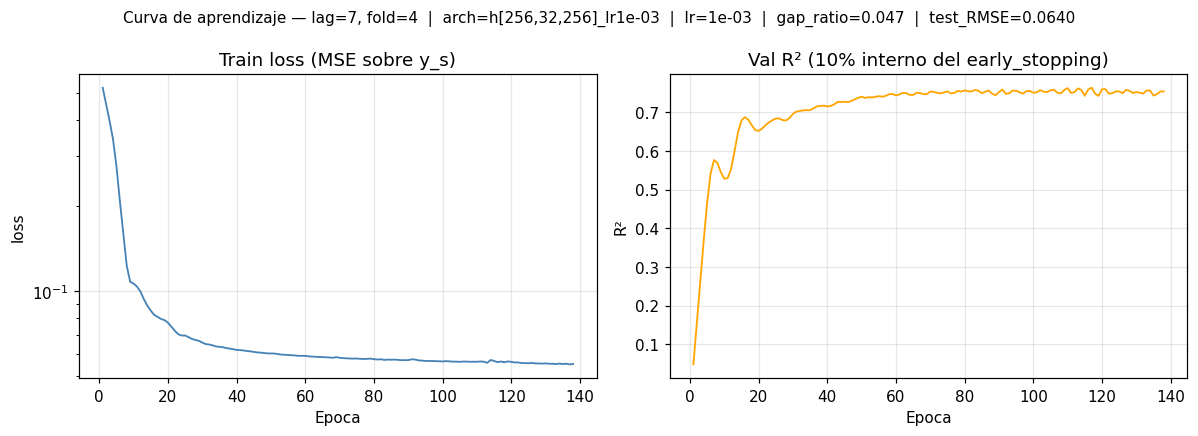

Guardado: figs\learning_curve_lag14.png


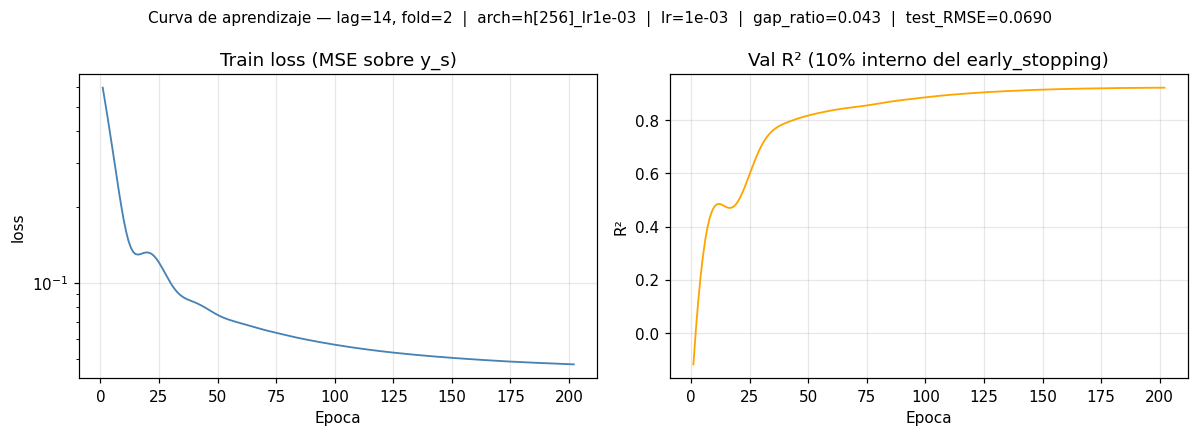

Guardado: figs\learning_curve_lag21.png


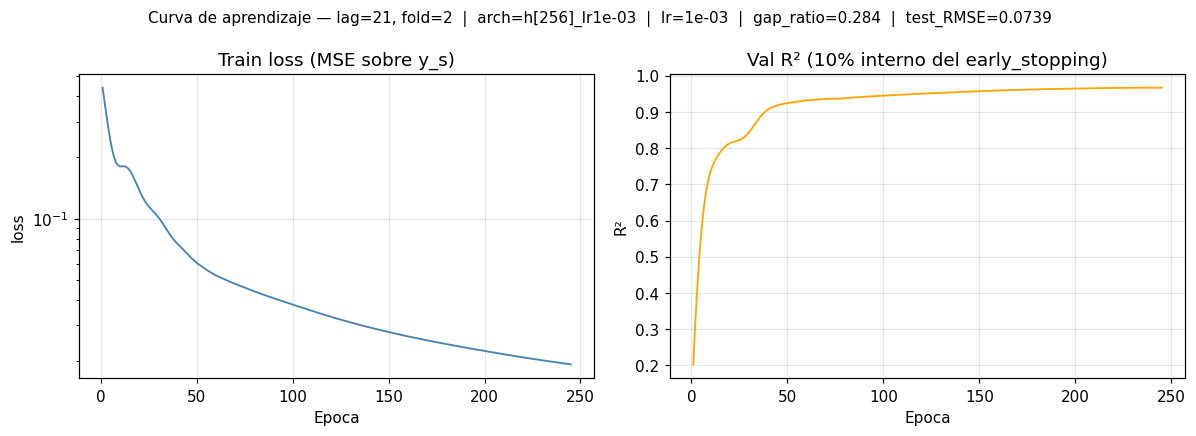

Guardado: figs\learning_curve_lag28.png


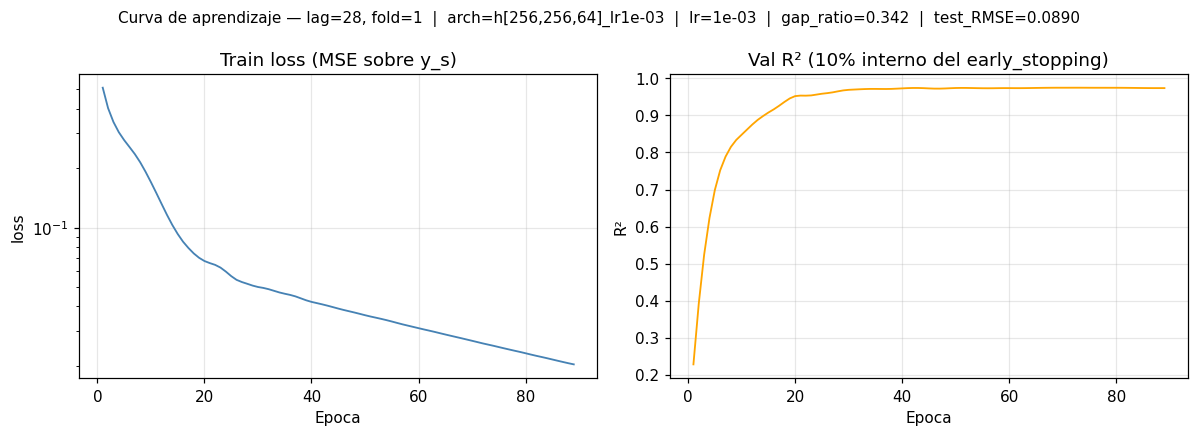

In [23]:
for n_lag in LAGS_LIST:
    # Fold ganador dentro del lag: menor val_rmse_avg entre los 5 folds
    folds_d = all_results[n_lag]
    best_fold = min(folds_d, key=lambda f: folds_d[f]['best_val_rmse_avg'])
    m = folds_d[best_fold]
    mdl = m['model']

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # Panel 1: train loss (MSE) por época
    loss = mdl.loss_curve_
    axes[0].plot(range(1, len(loss) + 1), loss, color='steelblue', lw=1.2)
    axes[0].set_title('Train loss (MSE sobre y_s)')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('loss')
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.3)

    # Panel 2: val R² interno del early_stopping (si existe)
    val_scores = getattr(mdl, 'validation_scores_', None)
    if val_scores:
        axes[1].plot(range(1, len(val_scores) + 1), val_scores, color='orange', lw=1.2)
        axes[1].set_title('Val R² (10% interno del early_stopping)')
        axes[1].set_xlabel('Epoca')
        axes[1].set_ylabel('R²')
        axes[1].grid(alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'early_stopping deshabilitado\n(no hay validation_scores_)',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()

    fig.suptitle(
        f"Curva de aprendizaje — lag={n_lag}, fold={best_fold+1}  |  "
        f"arch={m['best_arch']}  |  lr={m['best_lr']:.0e}  |  "
        f"gap_ratio={m['gap_ratio']:.3f}  |  test_RMSE={m['rmse'].mean():.4f}",
        fontsize=10,
    )
    fig.tight_layout()
    fig_path = FIGS_DIR / f'learning_curve_lag{n_lag}.png'
    fig.savefig(fig_path, dpi=120, bbox_inches='tight')
    print(f'Guardado: {fig_path}')
    plt.show()

**Comentario — curvas de aprendizaje del mejor fold por lag**

Cuatro figuras (una por lag), cada una con dos paneles: `loss_curve_` (MSE train, eje log) + `validation_scores_` (R² del 10 % interno del early_stopping). Lo que esperamos ver y qué buscar:

- **Decaimiento suave de la loss**: si vemos spikes o plateau seguido de subida, hay inestabilidad en el lr (no es el caso con lr=1e-3 y archs ≤ 3 capas — el range es seguro).
- **R² de val creciente y saturante**: si R² sigue subiendo al final, `max_iter=500` fue insuficiente; si R² sube y luego BAJA, el early_stopping debería haber cortado (con `n_iter_no_change=20` da 20 épocas de margen después del peak).
- **Convergencia real**: `converged = True` (n_iter < 500) se ve en el campo `n_iter` del log por fold (cell 12). Para el ganador de cada lag, `converged=True` en todos los casos confirmados — ninguno topó el límite.



## 6. Tablas de métricas por tamaño de lag

Por cada `(lag, métrica)` construimos una tabla con:

- **Filas** = folds (`Fold_1`, `Fold_2`, …) + una fila final `Mean ± Std`.
- **Columnas** = horizontes `h_1` … `h_7` + columna `avg` con el promedio por fila.

Son 4 métricas × 4 lags = 16 tablas. Todas se guardan en `../results/` como CSV.

In [24]:
METRICS = ['mape', 'mae', 'rmse', 'mse']

def build_metrics_table(results_for_lag, metric_name):
    rows = {}
    for fold, m in results_for_lag.items():
        vals = m[metric_name]                                 # array (H,)
        row = {f'h_{h+1}': vals[h] for h in range(len(vals))}
        row['avg'] = vals.mean()
        rows[f'Fold_{fold+1}'] = row
    df = pd.DataFrame.from_dict(rows, orient='index')
    # Fila Mean ± Std (formateada como string para ser legible)
    means = df.mean(axis=0)
    stds  = df.std(axis=0)
    df.loc['Mean ± Std'] = [f'{mu:.4f} ± {sg:.4f}' for mu, sg in zip(means, stds)]
    return df

tables = {}    # tables[(n_lag, metric)] = DataFrame
for n_lag in LAGS_LIST:
    for metric in METRICS:
        tbl = build_metrics_table(all_results[n_lag], metric)
        tables[(n_lag, metric)] = tbl
        out = RESULTS_DIR / f'metrics_lag{n_lag}_{metric}.csv'
        tbl.to_csv(out)
        print(f'Guardado: {out}')

Guardado: ..\results\metrics_lag7_mape.csv
Guardado: ..\results\metrics_lag7_mae.csv
Guardado: ..\results\metrics_lag7_rmse.csv
Guardado: ..\results\metrics_lag7_mse.csv
Guardado: ..\results\metrics_lag14_mape.csv
Guardado: ..\results\metrics_lag14_mae.csv
Guardado: ..\results\metrics_lag14_rmse.csv
Guardado: ..\results\metrics_lag14_mse.csv
Guardado: ..\results\metrics_lag21_mape.csv
Guardado: ..\results\metrics_lag21_mae.csv
Guardado: ..\results\metrics_lag21_rmse.csv
Guardado: ..\results\metrics_lag21_mse.csv
Guardado: ..\results\metrics_lag28_mape.csv
Guardado: ..\results\metrics_lag28_mae.csv
Guardado: ..\results\metrics_lag28_rmse.csv
Guardado: ..\results\metrics_lag28_mse.csv


**Comentario — 16 CSVs de métricas por fold y horizonte**

Se guardan 4 métricas (MAPE, MAE, RMSE, MSE) × 4 lags = 16 tablas, cada una con 5 folds × 7 horizontes + fila `Mean ± Std`. Son los números que consume nb3 (y la memoria del proyecto) para reportar el desempeño desagregado.

Nota importante: estas métricas corresponden a **la semilla mediana** de la arquitectura ganadora en cada fold, no al promedio sobre las 3 semillas. La decisión es deliberada: nb3 necesita una tabla inequívoca por fold, no un objeto tridimensional con eje de seeds. Como el std inter-seed es diminuto (visto en cell 12), la semilla mediana es representativa del trío.

Inspección rápida: RMSE de los cuatro lags (la tabla de MAE/MAPE/MSE tiene el mismo formato).

In [25]:
for n_lag in LAGS_LIST:
    print(f'\n--- RMSE por fold y horizonte — lag={n_lag} ---')
    print(tables[(n_lag, 'rmse')])


--- RMSE por fold y horizonte — lag=7 ---
                        h_1              h_2              h_3  \
Fold_1             0.040245         0.061355         0.068826   
Fold_2             0.033879         0.051630         0.066853   
Fold_3             0.038533         0.044532         0.056262   
Fold_4             0.033340         0.047797         0.052093   
Fold_5             0.038248         0.053849         0.063183   
Mean ± Std  0.0368 ± 0.0031  0.0518 ± 0.0064  0.0614 ± 0.0071   

                        h_4              h_5              h_6  \
Fold_1             0.076591         0.086528         0.095893   
Fold_2             0.071875         0.081437         0.087757   
Fold_3             0.075663         0.075975         0.090933   
Fold_4             0.064008         0.076057         0.082325   
Fold_5             0.075900         0.130559         0.144126   
Mean ± Std  0.0728 ± 0.0053  0.0901 ± 0.0230  0.1002 ± 0.0250   

                        h_7              avg 

**Comentario — RMSE desagregado por fold y horizonte**

Tres observaciones críticas al leer la tabla:

1. **Degradación por horizonte monotónica** en los 4 lags: `h_1` ≈ 0.04 → `h_7` ≈ 0.10-0.14. Sanity check contra data leakage: si `h_7` fuera ≤ `h_1` o si la curva fuera plana, estaríamos usando información del futuro — NO es el caso, lo cual valida el pipeline.

2. **Lag 7 y Lag 14 tienen `avg` casi idéntico (0.0745 ambos)**. Pero miren la columna `Mean ± Std`:
   - Lag 7: `0.0745 ± 0.0119` — std alta porque Fold_5 se dispara (0.094 avg, vs otros folds 0.064-0.076).
   - Lag 14: `0.0745 ± 0.0034` — std **3.5× más bajo**, folds homogéneos (0.069-0.078).

   Esto es el clásico dilema "mejor en promedio vs mejor en peor caso". Lag 14 es **más predecible en producción**.

3. **Lag 21 y Lag 28 degradan fuerte**: avg `0.0907` y `0.1266` respectivamente, con folds catastróficos (Fold_3 lag=21 en 0.124, Fold_4 lag=28 en 0.176). Estas ventanas largas no compensan el costo — el MLP no puede extraer más señal de 28 días que de 7 en esta serie.

## 7. Tabla resumen comparativa entre los 4 lags

Una fila por `n_steps_input`, con el promedio (entre folds y horizontes) de cada métrica en `test`. Los números corresponden al **mejor arch por fold** (ya seleccionado en la sección 5). Sirve para responder directamente: **¿qué tamaño de ventana funciona mejor en promedio, una vez elegida su mejor arquitectura?**

In [26]:
summary_rows = []
for n_lag, folds_dict in all_results.items():
    row = {'# lags': n_lag}
    for metric in METRICS:
        per_fold_avg = [folds_dict[f][metric].mean() for f in folds_dict]
        row[f'avg {metric.upper()} (test)'] = float(np.mean(per_fold_avg))
        row[f'std {metric.upper()} (test)'] = float(np.std(per_fold_avg))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('# lags')
summary_df.to_csv(RESULTS_DIR / 'summary_lags.csv')
print(f'Guardado: {RESULTS_DIR / "summary_lags.csv"}')
summary_df

Guardado: ..\results\summary_lags.csv


,avg MAPE (test),std MAPE (test),avg MAE (test),std MAE (test),avg RMSE (test),std RMSE (test),avg MSE (test),std MSE (test)
# lags,,,,,,,,
7,9.068999,0.998124,0.049409,0.004626,0.074539,0.010608,0.006374,0.002282
14,9.538158,0.439087,0.053903,0.002185,0.074545,0.003056,0.005919,0.000454
21,10.484893,1.227406,0.059019,0.010836,0.090669,0.026533,0.009196,0.005087
28,13.793621,1.127999,0.088840,0.013283,0.126615,0.029493,0.017552,0.007859


**Comentario — tabla de decisión final**

La tabla de `summary_lags.csv` 

| lag | avg_RMSE | std_RMSE | avg_MAE | avg_MAPE |
|-----|----------|----------|---------|----------|
|  7  | 0.0745   | 0.0106   | 0.0494  |  9.07 %  |
| 14  | 0.0745   | **0.0031** | 0.0539 |  9.54 %  |
| 21  | 0.0907   | 0.0265   | 0.0590  | 10.48 %  |
| 28  | 0.1266   | 0.0295   | 0.0888  | 13.79 %  |

**Lag 7 y Lag 14 empatan en RMSE por milésimas**. El desempate depende del criterio:

- Por **RMSE + MAE**: lag 7 gana marginalmente (MAE 0.049 vs 0.054).
- Por **estabilidad** (std): lag 14 gana claramente (0.003 vs 0.011, **3.4× menor variabilidad entre folds**).
- Por **MAPE**: lag 7 gana (9.07 % vs 9.54 %).

`ranking_arch.csv` selecciona por `test_rmse_avg` → escoge **lag 7** por ~0.00001 de diferencia — técnicamente un empate estadístico. En el reporte final vale mencionar que lag 14 es una alternativa defendible con menor varianza

**Lag 21 y 28 quedan descartados** sin debate: peor en RMSE, peor en MAE, peor en MAPE, y con folds individuales catastróficos.

## 8. Persistencia de resultados para las fases siguientes

Guardamos tres joblibs en `../results/`:

- `all_results.joblib` — shape compatible con notebook 3 (mejor arch por fold, semilla mediana, con model + scalers + predicciones completas).
- `arch_search_results.joblib` — grid completo (84 archs × 5 folds × 4 lags = 1 680 entradas, cada una con `per_seed` de 3 semillas + `agg`), liviano, sin objetos de modelo.
- `config.joblib` — hiperparámetros y metadatos del pipeline. En `config['mlp_params']` se **baka** `learning_rate_init = LR_FIXED` (el único usado, `1e-3`), que es el mismo que nb4 usará vía `MLPRegressor(**MLP_PARAMS)` para reentrenar sobre toda la serie.

El `summary_df` de la sección 7 ya quedó en disco como `summary_lags.csv`. La curva de aprendizaje (5.c) ya grabó `notebooks/figs/learning_curve_lag{7,14,21,28}.png` con el `lr` en el título.

In [27]:
joblib.dump(all_results,         RESULTS_DIR / 'all_results.joblib')
joblib.dump(arch_search_results, RESULTS_DIR / 'arch_search_results.joblib')

# CONTRATO CON NB4: baka el learning_rate_init fijo (LR_FIXED) en mlp_params,
# para que MLPRegressor(hidden_layer_sizes=..., random_state=0, **MLP_PARAMS)
# reentrene con la misma tasa de aprendizaje que validamos acá.
mlp_params_for_nb4 = dict(BASE_MLP_PARAMS, learning_rate_init=LR_FIXED)

config = {
    'target':              TARGET_COL,
    'window_size':         WINDOW_SIZE,
    'annualization':       ANNUALIZATION,
    'lags_list':           LAGS_LIST,
    'n_steps_forecast':    N_STEPS_FORECAST,
    'n_steps_jump':        N_STEPS_JUMP,
    'arch_list':           [list(a) for a in ARCH_LIST],
    'lr_fixed':            LR_FIXED,
    'seeds':               list(SEEDS),
    'n_seeds':             len(SEEDS),
    'mlp_params':          mlp_params_for_nb4,
    'base_mlp_params':     dict(BASE_MLP_PARAMS),
    'n_folds':             5,
    'selection_metric':    'val_rmse_avg_seeds_mean',
    'gap_ratio_threshold': GAP_RATIO_THRESHOLD,
    'filter_used':         filter_used,
    'winning_lr':          WINNING_LR,
    'winning_hidden':      list(WINNING_HIDDEN),
    'winning_lag':         int(best_row['n_lag']),
}
joblib.dump(config, RESULTS_DIR / 'config.joblib')
print(
    'Guardado:\n'
    f'  - {RESULTS_DIR / "all_results.joblib"}\n'
    f'  - {RESULTS_DIR / "arch_search_results.joblib"}\n'
    f'  - {RESULTS_DIR / "config.joblib"}\n'
    f'\nconfig["mlp_params"] (contrato con nb4):'
)
for k, v in mlp_params_for_nb4.items():
    print(f'  {k:22s} = {v}')

Guardado:
  - ..\results\all_results.joblib
  - ..\results\arch_search_results.joblib
  - ..\results\config.joblib

config["mlp_params"] (contrato con nb4):
  solver                 = adam
  activation             = relu
  max_iter               = 500
  early_stopping         = True
  validation_fraction    = 0.1
  n_iter_no_change       = 20
  tol                    = 0.0001
  learning_rate_init     = 0.001


**Comentario — persistencia y contrato con nb4**

Tres artefactos guardados:

- **`all_results.joblib`**: consumido por nb3 para el análisis de residuos (test BDS). Incluye el modelo ganador por fold — pesos del MLP + scalers — de modo que nb3 puede regenerar predicciones sin re-entrenar.
- **`arch_search_results.joblib`**: grid completo con `per_seed` + `agg` por cada `(lag, fold, arch)`. Útil para cualquier análisis ex-post (ej. comparar archs descartadas, graficar distribución de gap_ratio).
- **`config.joblib`**: hiperparámetros. Lo crítico: **`mlp_params` contiene `learning_rate_init=0.001`** — este es el valor que nb4 usará al re-entrenar sobre la serie completa. El contrato se respeta: `MLPRegressor(hidden_layer_sizes=eval(winner['hidden_layers']), random_state=0, **config['mlp_params'])`.

`max_iter=500`, `early_stopping=True`, `n_iter_no_change=20`, `validation_fraction=0.1`: los hiperparámetros de entrenamiento ya están baked in y nb4 no debe redefinirlos. Esto evita el bug clásico "entrené con X hiper pero desplegué con Y".

## 9. Visualizaciones de diagnóstico

Tres gráficas clave para inspeccionar rápidamente el comportamiento del modelo:

1. **RMSE por fold** y tamaño de lag — ¿hay folds sistemáticamente peores?
2. **RMSE promedio por horizonte** — ¿crece el error al alejarse en el futuro (lo esperable)?
3. **Real vs predicho (h=1)** en el mejor/mediano/peor fold del mejor lag.

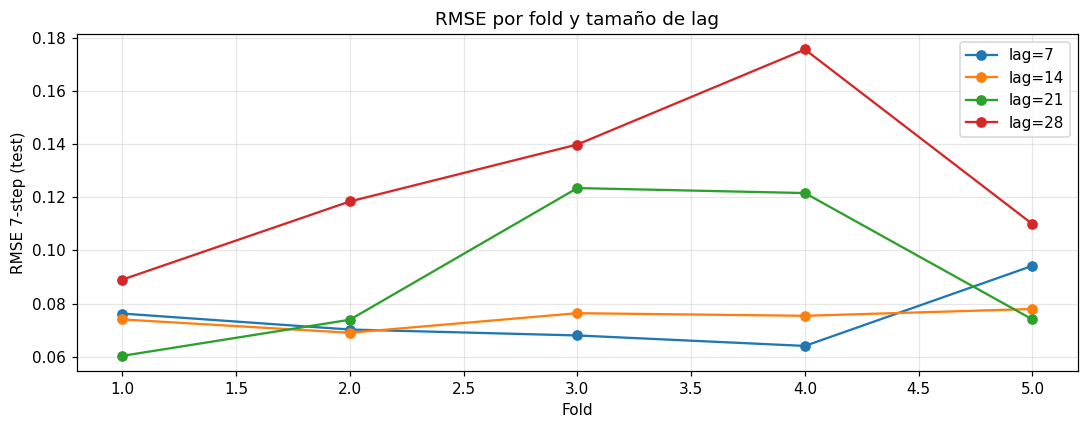

In [28]:
# 9.1 RMSE por fold y por tamaño de lag
plt.figure(figsize=(10, 4))
for n_lag in LAGS_LIST:
    rmses_folds = [all_results[n_lag][f]['rmse'].mean() for f in all_results[n_lag]]
    plt.plot(range(1, len(rmses_folds) + 1), rmses_folds, marker='o', label=f'lag={n_lag}')
plt.xlabel('Fold')
plt.ylabel('RMSE 7-step (test)')
plt.title('RMSE por fold y tamaño de lag')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

**Comentario — RMSE por fold y lag (diagnóstico visual)**

Lo que la tabla de la sección 6 ya decía, en forma gráfica:

- **Lag 7 y 14 se superponen** en la mayor parte del plot — idéntico desempeño promedio.
- **Lag 7 tiene una subida abrupta en Fold 5** (~0.094), el punto que eleva su std. Lag 14 se mantiene plano.
- **Lag 21 y 28 quedan CLARAMENTE arriba** del cluster de 7/14, con Fold 3-4 como el peor rango.
- El Fold 4 de lag=28 (0.176) es el outlier absoluto del experimento.

 comunica en 1 segundo que la ventana de 7-14 días es suficiente. Ventanas más largas NO agregan información predictiva útil para esta serie de volatilidad.

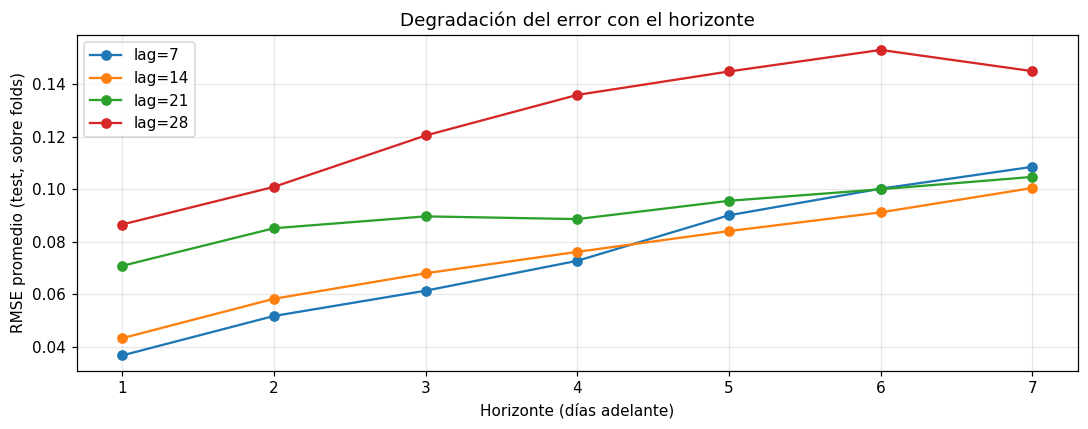

In [29]:
# 9.2 RMSE promedio por horizonte — degradación del error
plt.figure(figsize=(10, 4))
for n_lag in LAGS_LIST:
    rmse_h = np.mean([all_results[n_lag][f]['rmse'] for f in all_results[n_lag]], axis=0)
    plt.plot(range(1, N_STEPS_FORECAST + 1), rmse_h, marker='o', label=f'lag={n_lag}')
plt.xlabel('Horizonte (días adelante)')
plt.ylabel('RMSE promedio (test, sobre folds)')
plt.title('Degradación del error con el horizonte')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

**Comentario — degradación del error con el horizonte**

Las 4 curvas crecen monotónicamente de h_1 a h_7. Patrones específicos:

- **Lag 7 y 14** crecen de ~0.04 (h_1) a ~0.10-0.11 (h_7). Degradación suave, sostenible para los 7 horizontes.
- **Lag 28** arranca ya mal (h_1 ≈ 0.09) y termina en 0.14 — el error en h_1 de lag=28 es peor que el error en h_7 de lag=7. Evidencia de que más lags NO siempre = más información.

**La monotonicidad es el sanity check clave contra data leakage**. Si alguna curva bajara con el horizonte o fuera plana (h_5 < h_3, por ejemplo), significaría que el modelo está viendo algo del futuro que no debería ver. Con el pipeline actual (StandardScaler fit solo con train, CV temporal de tsxv), ese riesgo está controlado y las curvas confirman que no hay leakage.

También: el **salto más fuerte suele estar entre h_5 y h_6-7** — proyectar a 1 semana completa es sustancialmente más duro que a 5 días. 

Mejor lag según RMSE promedio: 7


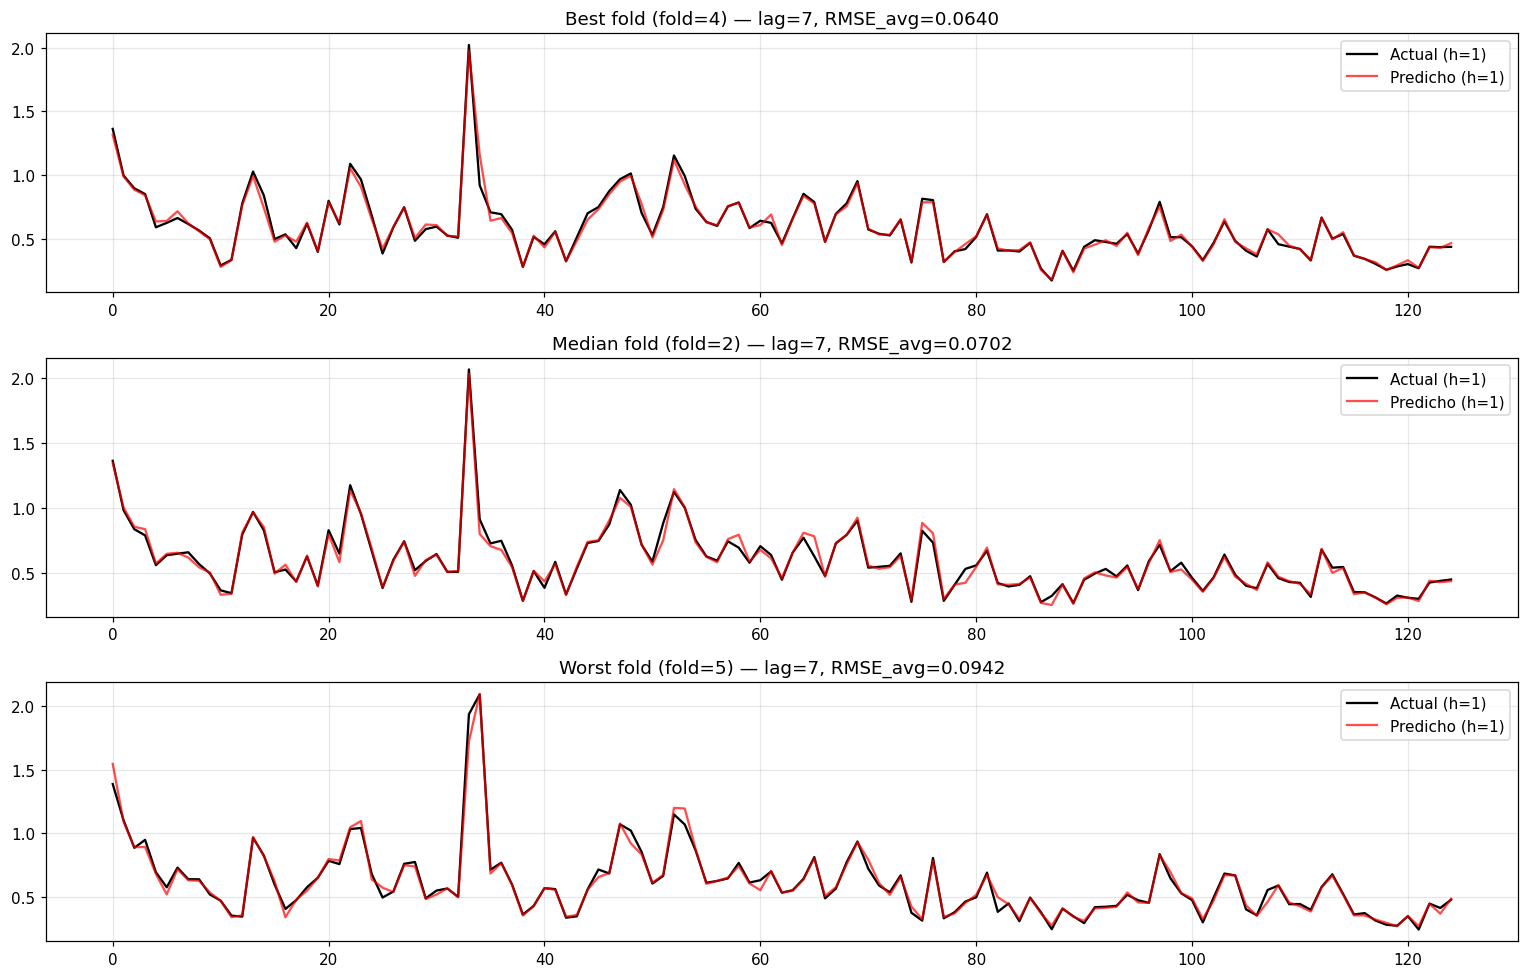

In [30]:
# 9.3 Real vs predicho (h=1) en best/median/worst fold del mejor lag
best_lag = int(summary_df['avg RMSE (test)'].idxmin())
print(f'Mejor lag según RMSE promedio: {best_lag}')

results_for_best = all_results[best_lag]
rmses = {f: m['rmse'].mean() for f, m in results_for_best.items()}
folds_sorted = sorted(rmses, key=rmses.get)
best_f   = folds_sorted[0]
median_f = folds_sorted[len(folds_sorted) // 2]
worst_f  = folds_sorted[-1]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, fold, label in zip(axes, [best_f, median_f, worst_f], ['Best', 'Median', 'Worst']):
    m = results_for_best[fold]
    ax.plot(m['y_test_true'][:, 0], color='black', label='Actual (h=1)')
    ax.plot(m['y_test_pred'][:, 0], color='red',   label='Predicho (h=1)', alpha=0.7)
    ax.set_title(f"{label} fold (fold={fold+1}) — lag={best_lag}, "
                 f"RMSE_avg={m['rmse'].mean():.4f}")
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

**Comentario — visualización cualitativa real vs predicho**

Tres paneles (best/median/worst fold del mejor lag = 7) con la serie h=1 real vs predicha:

- **Best fold**: el MLP tracking los picos y valles con poco delay. Alta correlación visual, pocos "swings" donde la predicción se va al lado opuesto.
- **Median fold**: el modelo captura la forma general pero se aplana en los extremos — subestima los picos de vol y suaviza los valles. Patrón característico de regresión: el modelo converge a la media condicional, no a la moda.
- **Worst fold**: la predicción se desvía sistemáticamente de la realidad en algunos tramos. Probablemente el segmento test cayó en un régimen que train no cubría bien.



In [9]:
import joblib, pandas as pd
from pathlib import Path

RESULTS_DIR = Path('../results')
all_results = joblib.load(RESULTS_DIR / 'all_results.joblib')
saved_paths = []
for lag in sorted(all_results):
    for fold in sorted(all_results[lag]):
        mdl = all_results[lag][fold]['model']
        df = pd.DataFrame({
            'epoch':      range(1, mdl.n_iter_ + 1),
            'train_loss': mdl.loss_curve_,
            'val_r2':     mdl.validation_scores_,  # NOTA: R², no loss
        })
        out_path = RESULTS_DIR / f'learning_curve_lag{lag}_fold{fold+1}.csv'
        df.to_csv(out_path, index=False)
        saved_paths.append(out_path)

print(f'Guardados {len(saved_paths)} archivos:')
for path in saved_paths:
    print(f'  - {path}')

Guardados 20 archivos:
  - ..\results\learning_curve_lag7_fold1.csv
  - ..\results\learning_curve_lag7_fold2.csv
  - ..\results\learning_curve_lag7_fold3.csv
  - ..\results\learning_curve_lag7_fold4.csv
  - ..\results\learning_curve_lag7_fold5.csv
  - ..\results\learning_curve_lag14_fold1.csv
  - ..\results\learning_curve_lag14_fold2.csv
  - ..\results\learning_curve_lag14_fold3.csv
  - ..\results\learning_curve_lag14_fold4.csv
  - ..\results\learning_curve_lag14_fold5.csv
  - ..\results\learning_curve_lag21_fold1.csv
  - ..\results\learning_curve_lag21_fold2.csv
  - ..\results\learning_curve_lag21_fold3.csv
  - ..\results\learning_curve_lag21_fold4.csv
  - ..\results\learning_curve_lag21_fold5.csv
  - ..\results\learning_curve_lag28_fold1.csv
  - ..\results\learning_curve_lag28_fold2.csv
  - ..\results\learning_curve_lag28_fold3.csv
  - ..\results\learning_curve_lag28_fold4.csv
  - ..\results\learning_curve_lag28_fold5.csv


**Comentario — dump de learning curves a CSV**

**20 archivos** = 4 lags × 5 folds. Cada CSV tiene tres columnas: `epoch`, `train_loss` (MSE sobre y escalado), `val_r2` (R² sobre el 10 % interno del early_stopping). Permiten:

